# Runtime + WCSS benchmark on UCI datasets

In [2]:
%load_ext autoreload
%autoreload 2

import io
import os
import tarfile
import time
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_covtype

from algorithms.coreset import coreset_kmeans
from algorithms.lloyd import lloyds_algorithm
from algorithms.local_search import local_search_kmeans

DATA_DIR = os.path.expanduser("~/.cache/kmeans_bench")
os.makedirs(DATA_DIR, exist_ok=True)

In [3]:
def wcss(X, centers):
    """Within-cluster sum of squares, chunked to avoid an (n, k) distance temp."""
    c_norm = np.einsum("ij,ij->i", centers, centers)
    total = 0.0
    for i in range(0, X.shape[0], 8192):
        chunk = X[i:i + 8192]
        x_norm = np.einsum("ij,ij->i", chunk, chunk)
        d2 = x_norm[:, None] - 2.0 * (chunk @ centers.T) + c_norm[None, :]
        total += float(np.maximum(d2.min(axis=1), 0.0).sum())
    return total


## Datasets

In [4]:
# Per-feature standardization — Covertype mixes binary and continuous columns;
# without scaling, Euclidean distance is dominated by Elevation.
covtype = fetch_covtype()
X_cov = covtype.data.astype(np.float64)
X_cov = (X_cov - X_cov.mean(axis=0)) / (X_cov.std(axis=0) + 1e-12)
print(f"Covertype: n={X_cov.shape[0]}, d={X_cov.shape[1]}")

Covertype: n=581012, d=54


In [5]:
# SIFT1M from corpus-texmex (INRIA). ~160 MB tarball, ~500 MB unpacked.
def read_fvecs(path):
    with open(path, "rb") as f:
        buf = f.read()
    a = np.frombuffer(buf, dtype=np.int32)
    d = a[0]
    return a.reshape(-1, d + 1)[:, 1:].copy().view(np.float32).astype(np.float32)


sift_path = os.path.join(DATA_DIR, "sift", "sift_base.fvecs")
if not os.path.exists(sift_path):
    url = "ftp://ftp.irisa.fr/local/texmex/corpus/sift.tar.gz"
    print(f"downloading {url} (~160 MB)...")
    with urllib.request.urlopen(url) as r:
        tarfile.open(fileobj=io.BytesIO(r.read())).extractall(DATA_DIR)
X_sift = read_fvecs(sift_path)
print(f"SIFT1M: n={X_sift.shape[0]}, d={X_sift.shape[1]}")

SIFT1M: n=1000000, d=128


In [6]:
SAMPLE_FRAC = 0.001
K = 10
CORESET_M = 200
MAX_SWAPS = 15

def time_it(fn):
    t0 = time.perf_counter()
    out = fn()
    return out, time.perf_counter() - t0

def bench(name, X):
    print(f"\n=== {name}  (n={X.shape[0]}, d={X.shape[1]}, k={K}) ===")
    rows = []
    algos = [
        ("Lloyd", lambda: lloyds_algorithm(X, K)),
        (f"Coreset (m={CORESET_M})", lambda: coreset_kmeans(X, K, CORESET_M)),
        (f"Local search (≤{MAX_SWAPS} swaps)",
         lambda: local_search_kmeans(X, K, max_swaps=MAX_SWAPS)),
    ]
    for label, fn in algos:
        (centers, _, _), t = time_it(fn)
        rows.append((label, t, wcss(X, centers)))
        print(f"  {label:<28}: {t:7.2f}s  WCSS={rows[-1][2]:.4e}")
    return rows

rng = np.random.default_rng(0)
results = {}
for name, X in [("Covertype", X_cov), ("SIFT1M", X_sift)]:
    n_sub = int(SAMPLE_FRAC * X.shape[0])
    idx = rng.choice(X.shape[0], size=n_sub, replace=False)
    results[name] = {"n": n_sub, "rows": bench(name, X[idx])}


=== Covertype  (n=581, d=54, k=10) ===
  Lloyd                       :    0.01s  WCSS=2.3573e+04
  Coreset (m=200)             :    0.00s  WCSS=2.2746e+04
  Local search (≤15 swaps)    :   36.53s  WCSS=2.4249e+04

=== SIFT1M  (n=1000, d=128, k=10) ===
  Lloyd                       :    0.04s  WCSS=8.1263e+07
  Coreset (m=200)             :    0.00s  WCSS=8.8121e+07
  Local search (≤15 swaps)    :  104.79s  WCSS=1.1687e+08


## Result

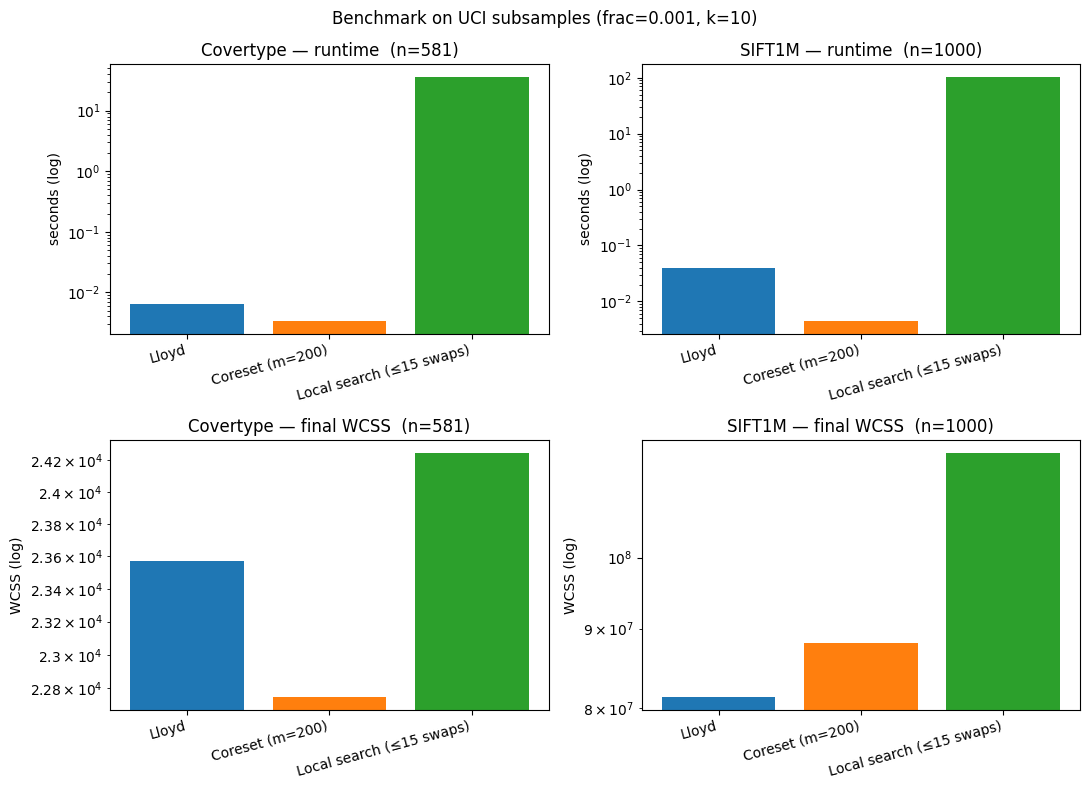

In [7]:
datasets = list(results.keys())
algo_names = [r[0] for r in results[datasets[0]]["rows"]]
colors = plt.cm.tab10.colors[:len(algo_names)]
x = np.arange(len(algo_names))

fig, axes = plt.subplots(2, len(datasets), figsize=(5.5 * len(datasets), 8),
                          squeeze=False)
for col, ds in enumerate(datasets):
    rows = results[ds]["rows"]
    n_sub = results[ds]["n"]
    axes[0, col].bar(x, [r[1] for r in rows], color=colors)
    axes[0, col].set_title(f"{ds} — runtime  (n={n_sub})")
    axes[0, col].set_ylabel("seconds (log)")
    axes[1, col].bar(x, [r[2] for r in rows], color=colors)
    axes[1, col].set_title(f"{ds} — final WCSS  (n={n_sub})")
    axes[1, col].set_ylabel("WCSS (log)")
    for ax in axes[:, col]:
        ax.set_xticks(x)
        ax.set_xticklabels(algo_names, rotation=15, ha="right")
        ax.set_yscale("log")

fig.suptitle(f"Benchmark on UCI subsamples (frac={SAMPLE_FRAC:g}, k={K})")
fig.tight_layout()
plt.show()